## 1 - Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2 - Importation et Nettoyage des données

In [2]:
df = pd.read_csv('netflix_titles.csv', sep = ";") # Importation des données
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce').fillna(0).astype(int) # convertit le type en int pour la colonne 'release_year'

## 3 - Compréhension glabale du fichier

In [3]:
df.head() # 5 premières lignes

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [4]:
df.shape # nombre de lignes et colonnes

(7789, 12)

In [5]:
df.info() # s'il y a des cases vides et le type de texte/nombre de chaque colonne.

<class 'pandas.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7789 non-null   str  
 1   type          7788 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7070 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7789 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   str  
 10  listed_in     7786 non-null   str  
 11  description   7786 non-null   str  
dtypes: int64(1), str(11)
memory usage: 730.3 KB


In [6]:
df.isnull().sum() # nombre exact de données manquantes par colonne.

show_id            0
type               1
title              2
director        2391
cast             719
country          509
date_added        12
release_year       0
rating             9
duration           2
listed_in          3
description        3
dtype: int64

In [7]:
df.nunique() # combien il y a d'éléments uniques

show_id         7789
type               3
title           7787
director        4049
cast            6832
country          682
date_added      1566
release_year      74
rating            15
duration         217
listed_in        492
description     7768
dtype: int64

In [8]:
df.sample(15) # 15 lignes au hasard

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6924,s6923,TV Show,The Terminal,NaN,"Mohammad Mansour, Bouthayna Al Raesi, Bassima ...",NaN,"March 29, 2019",2018,TV-14,1 Season,"International TV Shows, TV Dramas","Social pressure, a complicated past and a clas..."
1943,s1944,TV Show,El Barco,NaN,"Juanjo Artero, Mario Casas, Blanca Suárez, Ire...",Spain,"July 1, 2017",2013,NR,3 Seasons,"International TV Shows, Romantic TV Shows, Spa...",Forty young crew members traveling aboard a tr...
4079,s4080,TV Show,Midnight Misadventures With Mallika Dua,NaN,Mallika Dua,India,"April 1, 2019",2018,TV-14,1 Season,"International TV Shows, Stand-Up Comedy & Talk...","In this talk show, comedian Mallika Dua serves..."
5688,s5689,TV Show,Social Distance,NaN,"Danielle Brooks, Oscar Nuñez, Mike Colter, Hea...",United States,"October 15, 2020",2020,TV-MA,1 Season,"TV Comedies, TV Dramas","Filmed in isolation, this narrative anthology ..."
1716,s1717,Movie,Desperados,LP,"Nasim Pedrad, Anna Camp, Lamorne Morris, Heath...",United States,"July 3, 2020",2020,TV-MA,107 min,"Comedies, Romantic Movies","After drunkenly sending a cringeworthy email, ..."
4878,s4879,Movie,Planetarium,Rebecca Zlotowski,"Natalie Portman, Lily-Rose Depp, Emmanuel Sali...","France, Belgium","January 1, 2018",2016,TV-MA,108 min,"Dramas, International Movies","In pre-World War II France, two sisters purpor..."
4827,s4828,Movie,Perfect Bid: The Contestant Who Knew Too Much,C.J. Wallis,Theodore Slauson,Canada,"April 30, 2019",2017,TV-MA,72 min,Documentaries,"A ""Price Is Right"" superfan brings a bit of sc..."
5995,s5996,TV Show,Tayee,NaN,"Amr Youssef, Amr Abdel Guelil, Saba Mubarak",Egypt,"February 5, 2019",2018,TV-MA,1 Season,"International TV Shows, TV Dramas",An Egyptian doctor becomes a police informant ...
6,s7,Movie,122,Yasir Al Yasiri,"Amina Khalil, Ahmed Dawood, Tarek Lotfy, Ahmed...",Egypt,"June 1, 2020",2019,TV-MA,95 min,"Horror Movies, International Movies","After an awful accident, a couple admitted to ..."
659,s660,Movie,Baahubali: The Beginning (English Version),S.S. Rajamouli,"Prabhas, Rana Daggubati, Anushka Shetty, Taman...",NaN,"October 24, 2018",2015,TV-14,138 min,"Action & Adventure, Dramas, International Movies",Villagers in the kingdom of Mahismati rescue a...


In [9]:
df.describe()

,release_year
count,7789.000000
mean,2013.165875
std,40.470125
min,0.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


## 4 - Analyse des données

### 4.1 - Nombre de films et séries

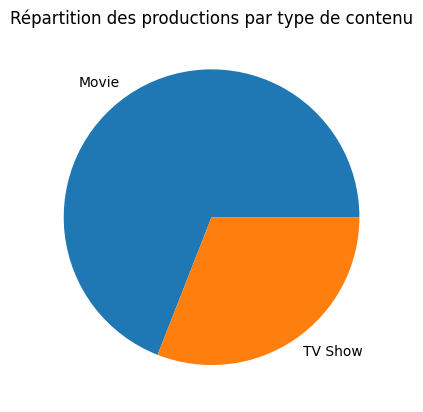

In [10]:
df = df[df['type'] != 'William Wyler']
df['type'].value_counts().plot(kind="pie")
plt.title("Répartition des productions par type de contenu")
plt.show()

In [11]:
df['type'].value_counts()

type
Movie      5377
TV Show    2410
Name: count, dtype: int64

### 4.2 - Evolution du nombre de films et séries au fil du temps

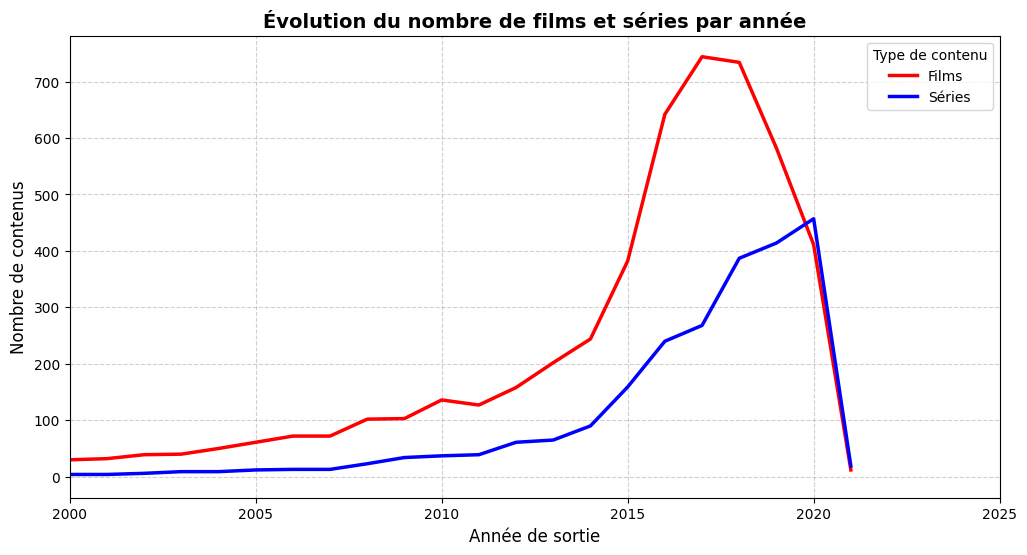

In [12]:
# 1. On compte le nombre de contenus par AN_DE_SORTIE et par TYPE en même temps
# .size() compte les lignes, .unstack(fill_value=0) sépare le résultat en deux colonnes distinctes
evol_catalogue = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)

# 2. On prépare la figure
plt.figure(figsize=(12, 6))

# 3. On trace la courbe des FILMS (en rouge)
sns.lineplot(x=evol_catalogue.index, y=evol_catalogue['Movie'], color='red', linewidth=2.5, label='Films')

# 4. On trace la courbe des SÉRIES (en bleu)
sns.lineplot(x=evol_catalogue.index, y=evol_catalogue['TV Show'], color='blue', linewidth=2.5, label='Séries')

# Construction du graphique
plt.title("Évolution du nombre de films et séries par année", fontsize=14, fontweight='bold')
plt.xlabel("Année de sortie", fontsize=12)
plt.ylabel("Nombre de contenus", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(2000, 2025) 

# Force l'affichage de la légende pour savoir quelle couleur correspond à quoi
plt.legend(title="Type de contenu")

plt.show()

In [13]:
tableau_evol = pd.crosstab(df['release_year'], df['type']).loc[2000:2021] # Tableau croisé (Années, Types) entre 2000 et 2021
tableau_evol['Total'] = tableau_evol['Movie'] + tableau_evol['TV Show'] # Nouvelle colonne : Total
tableau_evol

type,Movie,TV Show,Total
release_year,,,
2000,30,4,34
2001,32,4,36
2002,39,6,45
2003,40,9,49
2004,50,9,59
2005,61,12,73
2006,72,13,85
2007,72,13,85
2008,102,23,125


### 4.3 - Top 5 des pays avec le plus grand nombre de films et de séries

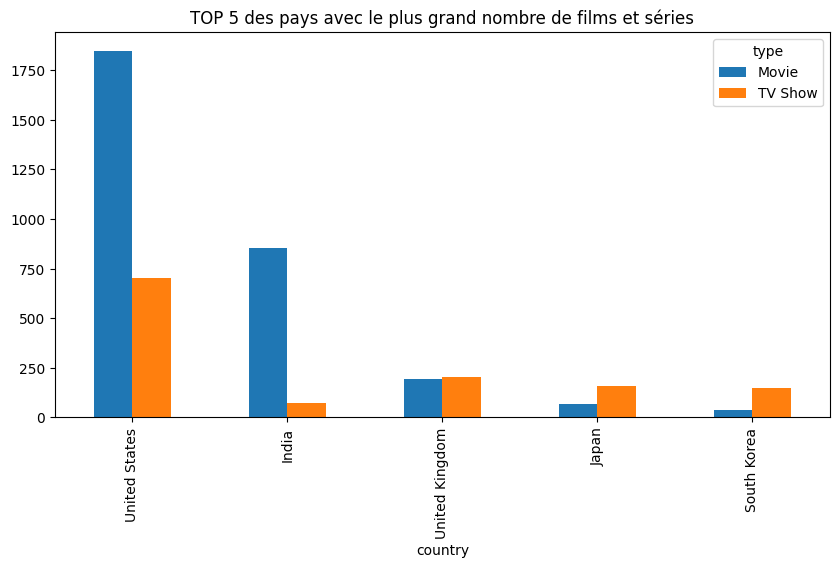

In [14]:
# 1. On crée le tableau croisé (Pays en lignes, Type en colonnes) pour le Top 5
top_5_noms = df['country'].value_counts().head(5).index # .index prend les noms
tableau_croise = pd.crosstab(df['country'], df['type']).loc[top_5_noms]

# 2. On dessine directement en barres groupées
tableau_croise.plot(kind="bar", figsize=(10, 5))
plt.title("TOP 5 des pays avec le plus grand nombre de films et séries")
plt.show()

#### Top 5 des pays avec le plus grand nombre de productions

In [15]:
df['country'].value_counts().head(5)

country
United States     2554
India              923
United Kingdom     397
Japan              226
South Korea        183
Name: count, dtype: int64

#### Top 5 des pays avec le plus grand nombre de films

In [16]:
df_movies = df[df['type'] == 'Movie'] # On filtre le dataset pour ne garder QUE les lignes où le type est 'Movie'
df_movies['country'].value_counts().head(5)

country
United States     1849
India              852
United Kingdom     193
Canada             118
Egypt               89
Name: count, dtype: int64

#### Top 5 des pays avec le plus grand nombre de séries

In [17]:
df_show = df[df['type'] == 'TV Show'] # On filtre le dataset pour ne garder QUE les lignes où le type est 'TV Show'
df_show['country'].value_counts().head(5)

country
United States     705
United Kingdom    204
Japan             157
South Korea       147
India              71
Name: count, dtype: int64

### 4.4 - Moyenne et Total : durées des films et nombre de saisons des séries

#### Durée moyenne des films par pays

In [18]:
# 1. On extrait les chiffres de la durée
df_movies['duration_num'] = df_movies['duration'].str.extract(r'(\d+)').astype(float)

# 2. On sépare les pays au niveau des virgules pour créer de vraies listes
df_pays_separes = df_movies.assign(country=df_movies['country'].str.split(', '))

# 3. On transforme chaque pays de la liste en une ligne unique
df_pays_separes = df_pays_separes.explode('country')

# 4. On fait le groupby sur les pays uniques !
top_duree_pays = df_pays_separes.groupby('country')['duration_num'].mean().sort_values(ascending=False)

# On affiche le résultat propre
top_duree_pays

country
Liechtenstein    200.000000
Montenegro       157.000000
Soviet Union     156.666667
Bahamas          145.000000
Morocco          137.333333
                    ...    
Georgia           71.500000
Namibia           69.500000
Guatemala         68.000000
Uganda            68.000000
Kazakhstan        67.000000
Name: duration_num, Length: 114, dtype: float64

#### Durée total de tous les films produits par pays

In [19]:
df_pays_separes.explode('country').groupby('country')['duration_num'].sum().sort_values(ascending=False)

country
United States     224408.0
India             115561.0
United Kingdom     45283.0
France             26484.0
Canada             25784.0
                    ...   
Afghanistan           84.0
Panama                81.0
United States,        77.0
Uganda                68.0
Kazakhstan            67.0
Name: duration_num, Length: 114, dtype: float64

#### Nombre moyen de saisons des séries par pays

In [20]:
# 1. On extrait les chiffres de la durée
df_show['duration_num'] = df_show['duration'].str.extract(r'(\d+)').astype(float)

# 2. On sépare les pays au niveau des virgules pour créer de vraies listes
df_pays_separes = df_show.assign(country=df_show['country'].str.split(', '))

# 3. On transforme chaque pays de la liste en une ligne unique
df_pays_separes = df_pays_separes.explode('country')

# 4. On fait le groupby sur les pays uniques !
top_duree_pays = df_pays_separes.groupby('country')['duration_num'].mean().sort_values(ascending=False)

# On affiche le résultat propre
top_duree_pays

country
Malta                   4.000000
Hungary                 3.000000
Canada                  2.785714
Ireland                 2.666667
Finland                 2.500000
                          ...   
Switzerland             1.000000
Syria                   1.000000
United Arab Emirates    1.000000
Uruguay                 1.000000
West Germany            1.000000
Name: duration_num, Length: 65, dtype: float64

#### Nombre total de saisons de toutes les séries produites par pays

In [21]:
df_pays_separes.explode('country').groupby('country')['duration_num'].sum().sort_values(ascending=False)

country
United States           2003.0
United Kingdom           478.0
Canada                   351.0
Japan                    292.0
South Korea              195.0
                         ...  
Mauritius                  1.0
Syria                      1.0
Switzerland                1.0
United Arab Emirates       1.0
Uruguay                    1.0
Name: duration_num, Length: 65, dtype: float64

#### Durée moyenne des films / Nombre moyen de saisons / Durée total de tous les films / Nombre de saisons total

In [22]:
# nouvelle colonne de durée où on extrait que le nombre (sans écrit "seasons" ou "min")
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

df.groupby('type')['duration_num'].agg(['mean', 'sum'])

,mean,sum
type,,
Movie,99.319010,533939.0
TV Show,1.775934,4280.0


### 4.5 - Evolution de la durée moyenne des films et du nombre moyens de saisons des séries

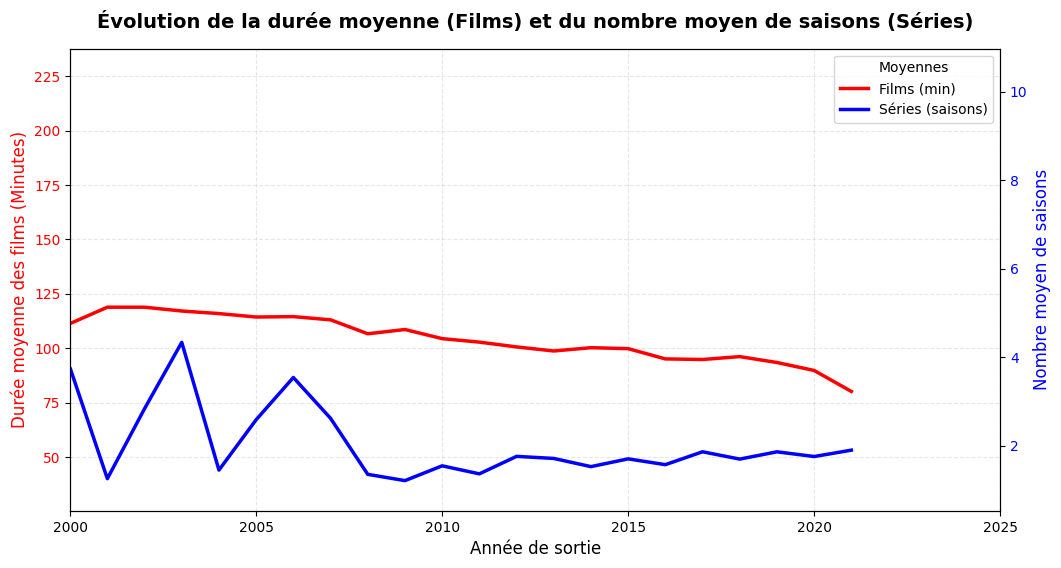

In [23]:
# --- ÉTAPE PRÉALABLE : Nettoyage et extraction des nombres ---
# On extrait les minutes pour les films
df['duration_movies'] = df[df['type'] == 'Movie']['duration'].str.extract(r'(\d+)').astype(float)
# On extrait les saisons pour les séries
df['duration_shows'] = df[df['type'] == 'TV Show']['duration'].str.extract(r'(\d+)').astype(float)

# Calcul des moyennes par année de sortie
moyennes_par_an = df.groupby('release_year')[['duration_movies', 'duration_shows']].mean()

# --- CONSTRUCTION DU GRAPHIQUE AVEC AXE SECONDAIRE ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. Courbe 1 (Axe Y Gauche) : Moyenne de la durée des films (en rouge)
color = 'red'
ax1.set_xlabel("Année de sortie", fontsize=12)
ax1.set_ylabel("Durée moyenne des films (Minutes)", color=color, fontsize=12)
sns.lineplot(data=moyennes_par_an, x=moyennes_par_an.index, y='duration_movies', color=color, linewidth=2.5, ax=ax1, label='Films (min)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.3)

# CRÉATION DE L'AXE SECONDAIRE
ax2 = ax1.twinx()  

# 2. Courbe 2 (Axe Y Droite) : Moyenne des saisons des séries (en blue)
color = 'blue'
ax2.set_ylabel("Nombre moyen de saisons", color=color, fontsize=12)
sns.lineplot(data=moyennes_par_an, x=moyennes_par_an.index, y='duration_shows', color=color, linewidth=2.5, ax=ax2, label='Séries (saisons)')
ax2.tick_params(axis='y', labelcolor=color)

# Gestion du zoom et des titres
plt.xlim(2000, 2025) # On s'arrête à 2021 car les données s'arrêtent là
plt.title("Évolution de la durée moyenne (Films) et du nombre moyen de saisons (Séries)", fontsize=14, fontweight='bold', pad=15)

# Regroupement des légendes des deux axes en une seule boîte
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.get_legend().remove() # On enlève la légende auto de l'axe 1
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', title="Moyennes")

plt.show()

In [24]:
df.groupby('release_year')[['duration_movies', 'duration_shows']].mean().loc[2000:2021]

,duration_movies,duration_shows
release_year,,
2000,111.366667,3.750000
2001,118.875000,1.250000
2002,118.871795,2.833333
2003,117.125000,4.333333
2004,115.940000,1.444444
2005,114.360656,2.583333
2006,114.541667,3.538462
2007,113.069444,2.615385
2008,106.666667,1.347826
